In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/processed/final_dataset.csv")

print(df.head())


                           order_id                       customer_id  \
0  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
1  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
2  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
3  53cdb2fc8bc7dce0b6741e2150273451  b0830fb4747a6c6d20dea0b8c802d7ef   
4  47770eb9100c2d0c44946d9cf07ec65d  41ce2a54c0b03bf3443c3d931a367089   

  order_status order_purchase_timestamp    order_approved_at  \
0    delivered      2017-10-02 10:56:33  2017-10-02 11:07:15   
1    delivered      2017-10-02 10:56:33  2017-10-02 11:07:15   
2    delivered      2017-10-02 10:56:33  2017-10-02 11:07:15   
3    delivered      2018-07-24 20:41:37  2018-07-26 03:24:27   
4    delivered      2018-08-08 08:38:49  2018-08-08 08:55:23   

  order_delivered_carrier_date order_delivered_customer_date  \
0          2017-10-04 19:55:00           2017-10-10 21:25:13   
1          2017-10-04 19:55:00           2017-10

In [2]:
print(df.info())
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 118434 entries, 0 to 118433
Data columns (total 32 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       118434 non-null  object 
 1   customer_id                    118434 non-null  object 
 2   order_status                   118434 non-null  object 
 3   order_purchase_timestamp       118434 non-null  object 
 4   order_approved_at              118258 non-null  object 
 5   order_delivered_carrier_date   116360 non-null  object 
 6   order_delivered_customer_date  115037 non-null  object 
 7   order_estimated_delivery_date  118434 non-null  object 
 8   month                          118434 non-null  int64  
 9   year                           118434 non-null  int64  
 10  customer_unique_id             118434 non-null  object 
 11  customer_zip_code_prefix       118434 non-null  int64  
 12  customer_city                 

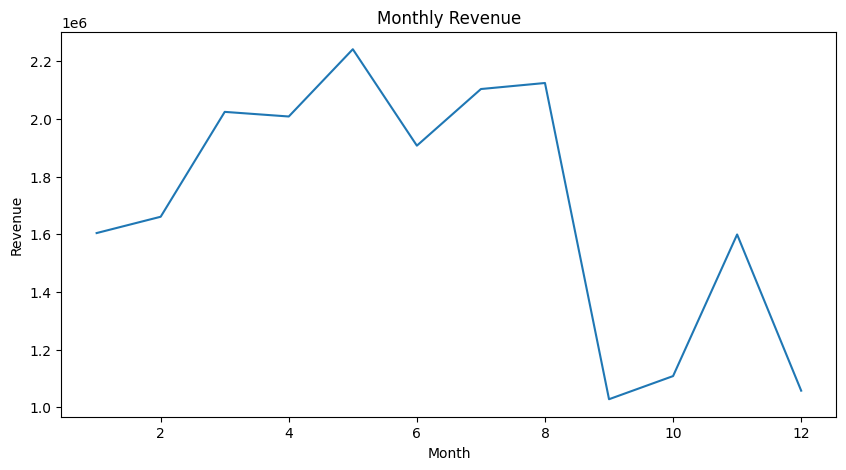

In [3]:
monthly_sales = df.groupby("month")["payment_value"].sum()

monthly_sales.plot(
    kind="line",
    figsize=(10,5),
    title="Monthly Revenue"
)

plt.xlabel("Month")
plt.ylabel("Revenue")

plt.show()

In [4]:
top_products = df.groupby("product_id")["payment_value"] \
    .sum() \
    .sort_values(ascending=False) \
    .head(10)

print(top_products)

product_id
5769ef0a239114ac3a854af00df129e4    109312.64
bb50f2e236e5eea0100680137654686c     81887.42
422879e10f46682990de24d770e7f83d     79512.22
d1c427060a0f73f6b889a5c7c61f2ac4     70557.90
6cdd53843498f92890544667809f1595     64825.67
d5991653e037ccb7af6ed7d94246b249     64143.26
aca2eb7d00ea1a7b8ebd4e68314663af     63788.12
a62e25e09e05e6faf31d90c6ec1aa3d1     63167.37
99a4788cb24856965c36a24e339b6058     63161.40
3dd2a17168ec895c781a9191c1e95ad7     58962.14
Name: payment_value, dtype: float64


In [5]:
state_sales = df.groupby("customer_state")["payment_value"] \
    .sum() \
    .sort_values(ascending=False)

print(state_sales.head(10))

customer_state
SP    7673188.55
RJ    2783724.26
MG    2341861.47
RS    1152019.17
PR    1074614.19
BA     802416.72
SC     799135.92
GO     516182.51
DF     434512.55
ES     406946.26
Name: payment_value, dtype: float64
